## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, recall_score, precision_score, f1_score
)

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Basic info
df.info()
print('\nMissing values:\n', df.isnull().sum())
print('\nChurn distribution:\n', df['Churn Label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Churn Rate (%):
 Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


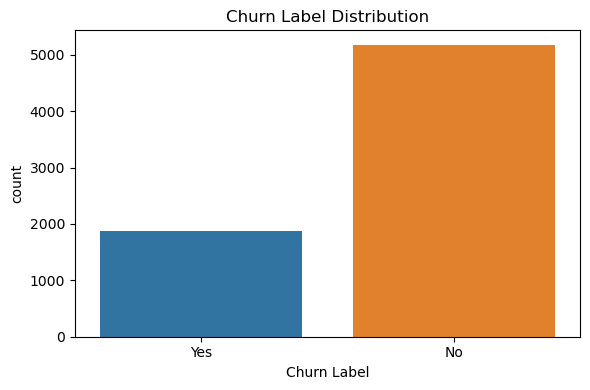

In [4]:
# Churn rate
churn_rate = df['Churn Label'].value_counts(normalize=True) * 100
print('Churn Rate (%):\n', churn_rate.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Label Distribution')
plt.tight_layout()
plt.show()

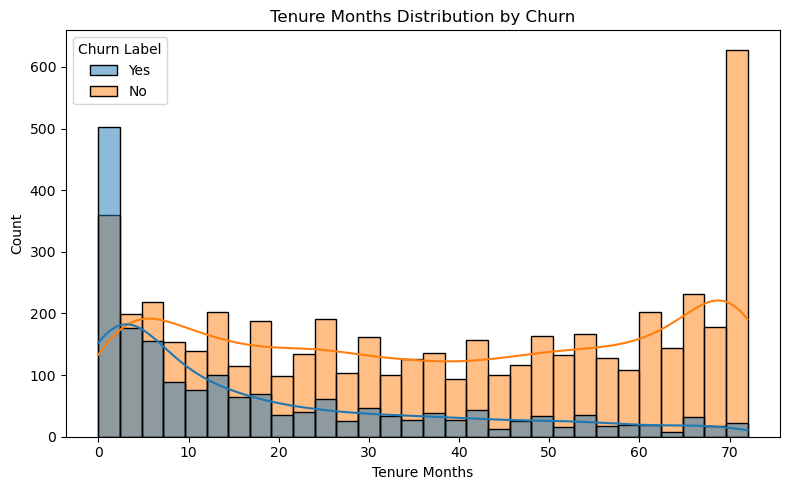

In [5]:
# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30, kde=True)
plt.title('Tenure Months Distribution by Churn')
plt.tight_layout()
plt.show()


In [6]:
print('Average Tenure by Churn Label:')
print(df.groupby('Churn Label')['Tenure Months'].mean())

Average Tenure by Churn Label:
Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64


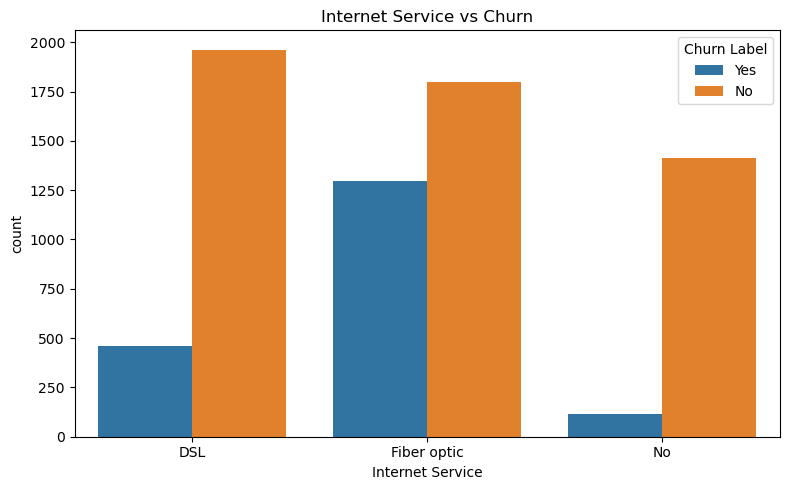

In [7]:
# Internet Service vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.title('Internet Service vs Churn')
plt.tight_layout()
plt.show()

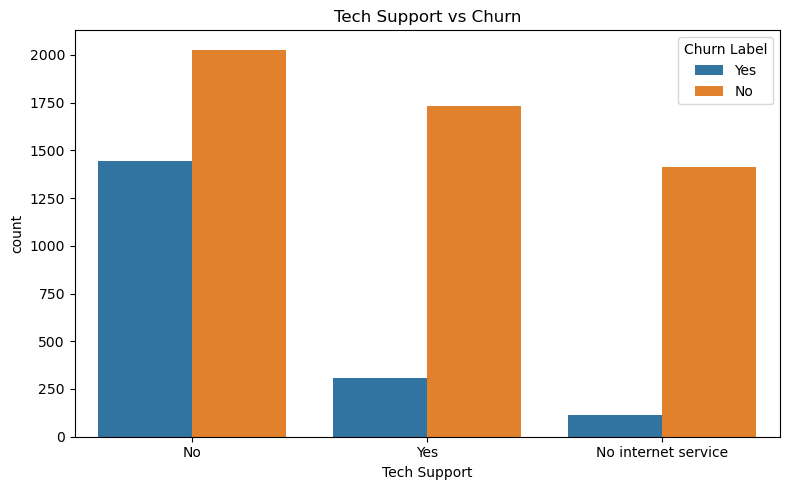

In [8]:
# Tech Support vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.title('Tech Support vs Churn')
plt.tight_layout()
plt.show()

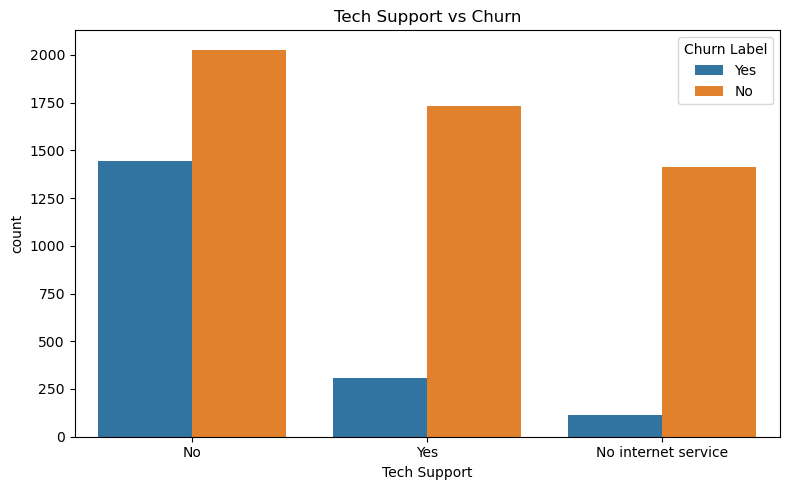

In [9]:
# Tech Support vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.title('Tech Support vs Churn')
plt.tight_layout()
plt.show()

In [10]:
# Contract type vs Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
print('Churn Rate by Contract Type:\n', contract_churn.round(3))

Churn Rate by Contract Type:
 Churn Label        No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


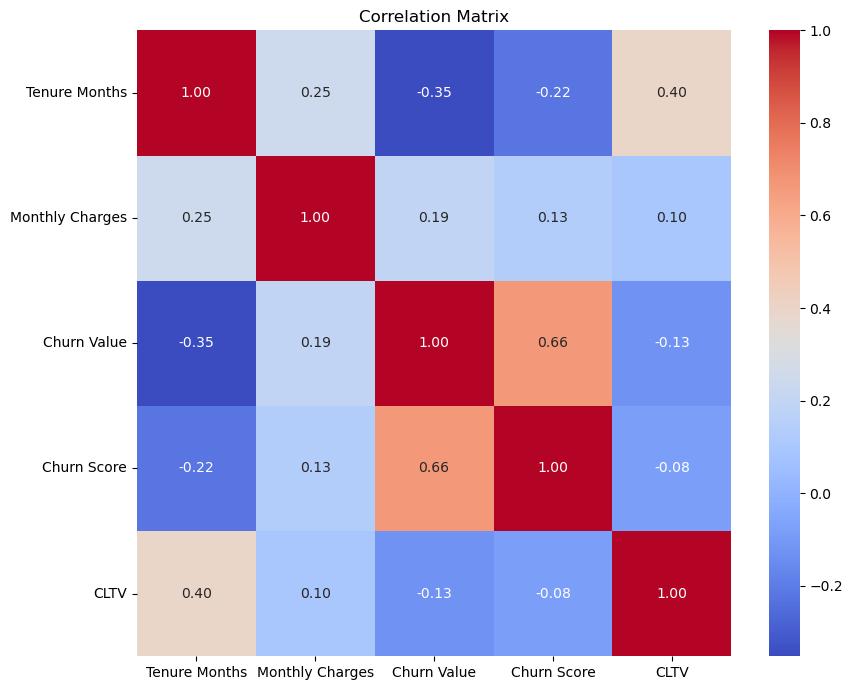

In [11]:
# Correlation heatmap (numeric cols only)
num_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [12]:
# Fix Total Charges (stored as object in some versions)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [13]:
# Customers with 0 tenure → Total Charges is NaN → fill with 0
print('NaN in Total Charges:', df['Total Charges'].isnull().sum())
print('Rows with NaN tenure:', df[df['Total Charges'].isnull()]['Tenure Months'].tolist())
df['Total Charges'] = df['Total Charges'].fillna(0)
print('After fix — NaN count:', df['Total Charges'].isnull().sum())

NaN in Total Charges: 11
Rows with NaN tenure: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
After fix — NaN count: 0


In [14]:
# Drop columns not useful for modelling
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
    'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

In [15]:
df_model = df.drop(columns=drop_cols)
print('Modelling DataFrame shape:', df_model.shape)
df_model.info()

Modelling DataFrame shape: (7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null  

## 4. Feature Engineering — One-Hot Encoding


In [16]:
df_enc = pd.get_dummies(df_model, drop_first=True)
print('Encoded shape:', df_enc.shape)
df_enc.head()

Encoded shape: (7043, 31)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [17]:
X = df_enc.drop('Churn Value', axis=1)
y = df_enc['Churn Value']
print('Features:', X.shape, '| Target:', y.shape)
print('Class balance:\n', y.value_counts())

Features: (7043, 30) | Target: (7043,)
Class balance:
 Churn Value
0    5174
1    1869
Name: count, dtype: int64


## 5. Train / Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (5634, 30) | Test: (1409, 30)


## 6. Baseline Random Forest

In [19]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

In [20]:
print('Baseline Accuracy:', accuracy_score(y_test, y_pred_base).round(4))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_base))
print('\nClassification Report:\n', classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.7928

Confusion Matrix:
 [[920 115]
 [177 197]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## 7. Approach 1 — Handle Class Imbalance (class_weight='balanced')

In [21]:
rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

In [22]:
rf_bal.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
y_pred_bal = rf_bal.predict(X_test)

In [24]:
print('Balanced Accuracy:', accuracy_score(y_test, y_pred_bal).round(4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_bal))

Balanced Accuracy: 0.7977

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 8. Approach 2 — Hyperparameter Tuning (max_depth + n_estimators grid)


In [25]:
n_est_list  = [100, 200, 300, 400, 500]
depth_list  = [5, 10, 15]
results     = []

In [26]:
for n in n_est_list:
    for d in depth_list:
        rf = RandomForestClassifier(
            n_estimators=n, max_depth=d,
            random_state=42, class_weight='balanced'
        )
        rf.fit(X_train, y_train)
        yp = rf.predict(X_test)
        results.append({
            'Trees': n, 'Depth': d,
            'Accuracy':  accuracy_score(y_test, yp),
            'Recall':    recall_score(y_test, yp),
            'Precision': precision_score(y_test, yp),
            'F1':        f1_score(y_test, yp)
        })

In [27]:
results_df = pd.DataFrame(results).sort_values(['Recall', 'Accuracy'], ascending=False)
print(results_df.to_string(index=False))

 Trees  Depth  Accuracy   Recall  Precision       F1
   200      5  0.747339 0.826203   0.515000 0.634497
   300      5  0.745209 0.826203   0.512438 0.632549
   400      5  0.745209 0.826203   0.512438 0.632549
   100      5  0.745919 0.820856   0.513378 0.631687
   500      5  0.743080 0.820856   0.509967 0.629098
   100     10  0.771469 0.740642   0.551793 0.632420
   500     10  0.772889 0.737968   0.554217 0.633028
   300     10  0.771469 0.737968   0.552000 0.631579
   400     10  0.773598 0.735294   0.555556 0.632911
   200     10  0.771469 0.735294   0.552209 0.630734
   100     15  0.793471 0.606952   0.611860 0.609396
   300     15  0.790632 0.604278   0.605898 0.605087
   400     15  0.789212 0.598930   0.603774 0.601342
   200     15  0.788502 0.598930   0.602151 0.600536
   500     15  0.788502 0.593583   0.603261 0.598383


### Best model from grid (max_depth=10, n_estimators=200, class_weight='balanced')

In [28]:
rf_tuned = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=42, class_weight='balanced'
)

In [29]:
rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

In [30]:
print('Tuned Classification Report:\n', classification_report(y_test, y_pred_tuned))

Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## 9. Approach 3 — Feature Importance & Selection

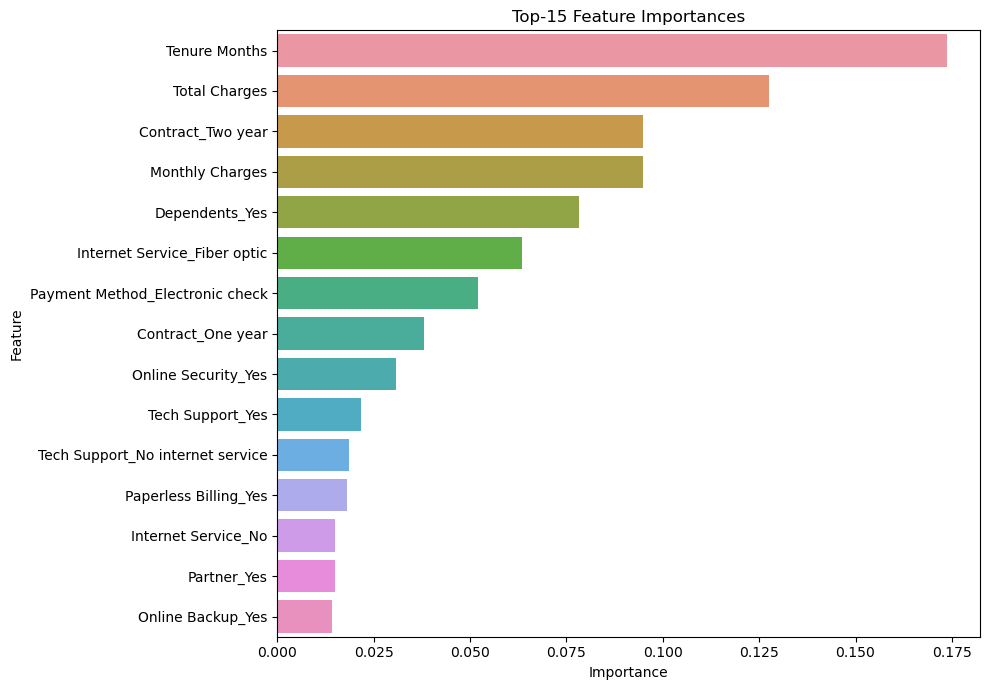


Bottom-5 features (candidates to drop):
                              Feature  Importance
17              Device Protection_Yes    0.008886
29        Payment Method_Mailed check    0.008505
14  Online Backup_No internet service    0.007158
8     Multiple Lines_No phone service    0.003945
7                   Phone Service_Yes    0.003827


In [31]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top-15 Feature Importances')
plt.tight_layout()
plt.show()

print('\nBottom-5 features (candidates to drop):')
print(feat_imp.tail(5))

In [32]:
# Drop very low-importance features
low_imp_feats = ['Phone Service_Yes', 'Multiple Lines_No phone service']
X_sel = X.drop(columns=low_imp_feats)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
rf_sel = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    random_state=42, class_weight='balanced'
)

In [34]:
rf_sel.fit(X_tr_s, y_tr_s)
y_pred_sel = rf_sel.predict(X_te_s)
print('Selected-Feature Report:\n', classification_report(y_te_s, y_pred_sel))

Selected-Feature Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## 10. Cross-Validation (final model)

In [35]:
final_rf = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    random_state=42, class_weight='balanced'
)

In [36]:
cv_acc    = cross_val_score(final_rf, X, y, cv=5, scoring='accuracy')
cv_recall = cross_val_score(final_rf, X, y, cv=5, scoring='recall')

In [37]:
print(f'CV Accuracy : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'CV Recall   : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}')

CV Accuracy : 0.7792  ± 0.0135
CV Recall   : 0.7330  ± 0.0256


## 11. ROC-AUC Curve

In [38]:
y_prob     = rf_tuned.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)

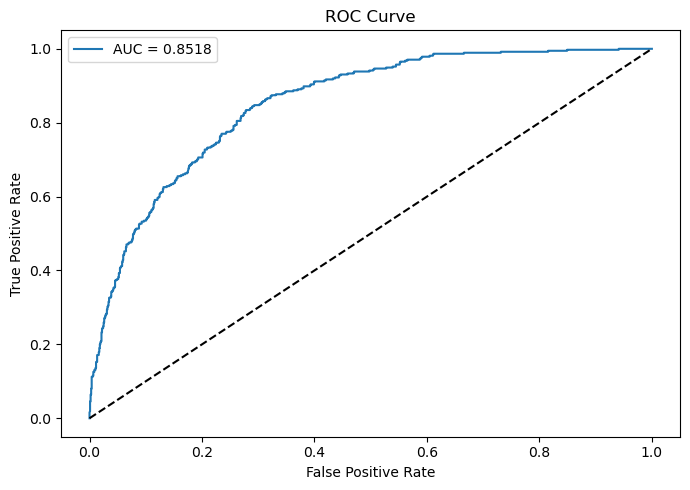

In [39]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
print(f'AUC Score: {auc:.4f}')

AUC Score: 0.8518


## 12. Customer Segmentation with K-Means

In [69]:
seg_df = pd.DataFrame({
    'Tenure Months':   X_test['Tenure Months'].values,
    'Monthly Charges': X_test['Monthly Charges'].values,
    'Total Charges':   X_test['Total Charges'].values,
    'Churn Prob':      y_prob
})

In [70]:
scaler      = StandardScaler()
scaled_seg  = scaler.fit_transform(seg_df)
print('Scaled data shape:', scaled_seg.shape)

Scaled data shape: (1409, 4)


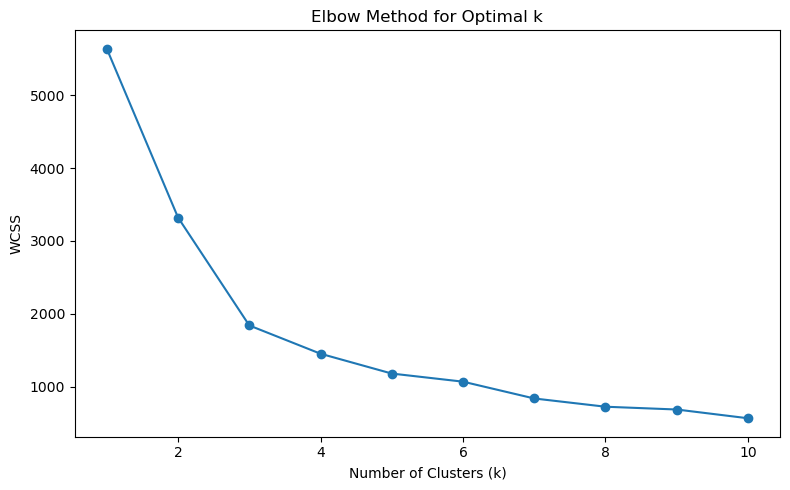

In [74]:
# Elbow method to choose k
import warnings
from sklearn.exceptions import ConvergenceWarning

wcss = []
K_range = range(1, 11)
with warnings.catch_warnings():                          
    warnings.simplefilter('ignore', ConvergenceWarning)
    warnings.simplefilter('ignore', FutureWarning)
    warnings.simplefilter('ignore', UserWarning)
    for k in K_range:
            km = KMeans(n_clusters=k, random_state=42, n_init='auto')
            km.fit(scaled_seg)
            wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

In [75]:
# Fit with k=3 (elbow typically around 3)
kmeans   = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(scaled_seg)
seg_df['Cluster'] = clusters


C:\Users\pooja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [76]:
print('Cluster sizes:')
print(seg_df['Cluster'].value_counts().sort_index())

print('\nCluster means:')
print(seg_df.groupby('Cluster').mean().round(3))

Cluster sizes:
Cluster
0    484
1    391
2    534
Name: count, dtype: int64

Cluster means:
         Tenure Months  Monthly Charges  Total Charges  Churn Prob
Cluster                                                           
0               33.298           33.395       1114.017       0.126
1               58.724           90.997       5341.652       0.227
2               11.034           72.206        887.541       0.680


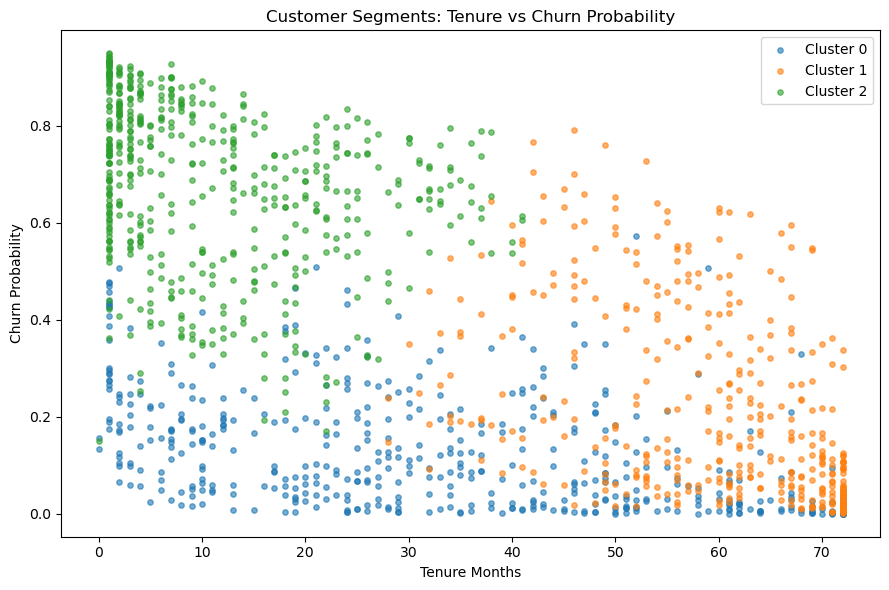

In [77]:
# Visualise: Tenure vs Churn Prob coloured by cluster
plt.figure(figsize=(9, 6))
for c in sorted(seg_df['Cluster'].unique()):
    sub = seg_df[seg_df['Cluster'] == c]
    plt.scatter(sub['Tenure Months'], sub['Churn Prob'],
                label=f'Cluster {c}', alpha=0.6, s=15)
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.title('Customer Segments: Tenure vs Churn Probability')
plt.legend()
plt.tight_layout()
plt.show()